# SisFall — AFD-CNN Training Notebook (4 s Windows: Peak for Falls, Random for ADLs)

Same model and class mapping as `SisFall_train_peak_random_balanced.ipynb`, but the **input representation changes**:

Instead of 2 s repeated twice (600 values duplicated → 1200), each recording contributes a **4 s window (400 samples @ 100 Hz)** across 3 ADXL345 axes → **400 × 3 = 1200 values** fed directly to the CNN.

### Windowing strategy

**Fall class (label 0):** one window per recording, centred on the global-maximum peak of ‖a‖.

**Non-fall / ADL classes:** one randomly-positioned 4 s window per recording.

### Per-class balancing
| Situation | Action |
|---|---|
| candidates ≥ TARGET | randomly sample TARGET without replacement |
| candidates < TARGET | keep all + random oversample with replacement to reach TARGET |

TARGET = number of fall peak windows, capped by `TARGET_COUNT` (nominally 298).

Checkpoint → `model/sisfall_peak4s_random_balanced_model.ckpt`  
CSVs → `data/sisfall_peak4s_random_balanced_{train,test}.csv`

**SisFall activity → class mapping:**

| SisFall codes | Class label | Activity |
|---|---|---|
| F01–F15 | 0 | **Fall** |
| D01, D02 | 2 | Walk |
| D03, D04 | 3 | Jog |
| D19 | 4 | Jump |
| D05 | 5 | Up-stairs |
| D06 | 6 | Down-stairs |
| D07, D08 | 7 | Stand→Sit |
| D09, D10 | 9 | Sit→Stand |

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

import importlib, cnn as cnn_module
importlib.reload(cnn_module)

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)

I0000 00:00:1776884153.955501   75593 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
non-resource variables are not supported in the long term
TensorFlow version: 2.21.0
NumPy version: 2.4.4


## 2. Configuration

In [2]:
SISFALL_PATH    = 'SisFall_dataset'
MODEL_SAVE_PATH = 'model/sisfall_peak4s_random_balanced_model.ckpt'
TRAIN_CSV       = 'data/sisfall_peak4s_random_balanced_train.csv'
TEST_CSV        = 'data/sisfall_peak4s_random_balanced_test.csv'

CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
CLASS_NUM   = len(CLASS_LIST)
CLASS_NAMES = {
    0: 'Fall', 2: 'Walk', 3: 'Jog', 4: 'Jump',
    5: 'Up-stairs', 6: 'Down-stairs', 7: 'Stand\u2192Sit', 9: 'Sit\u2192Stand'
}

CODE_TO_LABEL = {
    **{f'F{i:02d}': 0 for i in range(1, 16)},
    'D01': 2, 'D02': 2,
    'D03': 3, 'D04': 3,
    'D19': 4,
    'D05': 5,
    'D06': 6,
    'D07': 7, 'D08': 7,
    'D09': 9, 'D10': 9,
}

WINDOW      = 400   # 4 s at 100 Hz  (400 × 3 = 1200 values, no repeat needed)
HALF_WINDOW = WINDOW // 2

TARGET_COUNT = 298
TEST_SIZE    = 0.20
RANDOM_SEED  = 42

print('Classes:', CLASS_LIST)
print('Activity codes tracked:', sorted(CODE_TO_LABEL.keys()))
print(f'Window: {WINDOW} samples = {WINDOW / 100:.0f} s at 100 Hz  →  {WINDOW * 3} values per sample')
print(f'Configured target per class: {TARGET_COUNT}')

Classes: [0, 2, 3, 4, 5, 6, 7, 9]
Activity codes tracked: ['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D19', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15']
Window: 400 samples = 4 s at 100 Hz  →  1200 values per sample
Configured target per class: 298


## 3. Helper Functions

In [3]:
def parse_sisfall_txt(filepath):
    """Read a SisFall .txt file → float32 array (N, 9) of raw ADC values."""
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip().rstrip(';')
            if not line:
                continue
            try:
                parts = [int(x.strip()) for x in line.split(',')]
                if len(parts) == 9:
                    rows.append(parts)
            except ValueError:
                pass
    return np.array(rows, dtype=np.float32) if rows else None


def normalize_adxl345(raw):
    """Map ADXL345 13-bit ADC values in [-4096, 4095] linearly to [0, 255]."""
    return np.clip((raw + 4096.0) / 8192.0 * 255.0, 0.0, 255.0)


def extract_peak_window(arr, window=400):
    """
    Single max-peak window from arr (T, 3), centred on the sample with
    the highest vector magnitude.  Clamped to recording boundaries.
    Returns (window_arr, peak_idx) or (None, None) if the recording is too short.
    """
    n = len(arr)
    if n < window:
        return None, None
    magnitude = np.linalg.norm(arr, axis=1)
    peak_idx  = int(np.argmax(magnitude))
    start     = max(0, min(peak_idx - window // 2, n - window))
    return arr[start:start + window], peak_idx


def extract_random_window(arr, window=400, rng=None):
    """
    Single randomly-positioned window from arr (T, 3).
    Returns (window_arr, start_idx) or (None, None) if the recording is too short.
    """
    n = len(arr)
    if n < window:
        return None, None
    max_start = n - window
    start = int(rng.integers(0, max_start + 1)) if rng is not None else np.random.randint(0, max_start + 1)
    return arr[start:start + window], start


print('Helper functions defined.')

Helper functions defined.


## 4. Collect Windows and Balance Classes

Falls keep one global max-peak window per recording.  
Every non-fall label uses one randomly-positioned 4 s window per recording, then all labels are balanced to the same target count.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)

skip_prefixes = {'desktop', 'Links', 'Readme'}

# ── Stage 1: collect one window per recording ──────────────────────────────
# Falls     → peak-centred window
# Non-falls → random-position window
candidate_windows = {lbl: [] for lbl in CLASS_LIST}  # label → [(flat_1200,)]
recording_counts  = {lbl: 0 for lbl in CLASS_LIST}

for subj in sorted(os.listdir(SISFALL_PATH)):
    subj_path = os.path.join(SISFALL_PATH, subj)
    if not os.path.isdir(subj_path):
        continue

    for fname in sorted(os.listdir(subj_path)):
        if not fname.endswith('.txt'):
            continue
        if any(fname.startswith(p) for p in skip_prefixes):
            continue

        code = fname.split('_')[0]
        if code not in CODE_TO_LABEL:
            continue

        label = CODE_TO_LABEL[code]

        raw = parse_sisfall_txt(os.path.join(subj_path, fname))
        if raw is None or len(raw) < WINDOW * 2:   # need ≥ WINDOW rows after downsample
            continue

        raw_ds  = raw[::2]        # downsample 200 Hz → 100 Hz
        acc_raw = raw_ds[:, 0:3]  # ADXL345 columns
        recording_counts[label] += 1

        if label == 0:
            win_raw, _ = extract_peak_window(acc_raw, window=WINDOW)
        else:
            win_raw, _ = extract_random_window(acc_raw, window=WINDOW, rng=rng)

        if win_raw is not None:
            win_norm = normalize_adxl345(win_raw)  # (400, 3)
            candidate_windows[label].append(
                win_norm.flatten().astype(np.float32)   # (1200,)
            )

# ── Stage 2: balance every class to exactly TARGET samples ─────────────────
n_falls = len(candidate_windows[0])
TARGET  = min(n_falls, TARGET_COUNT)
if TARGET < 2:
    raise ValueError(f'Not enough fall windows to create a balanced split: TARGET={TARGET}')

print(f'Fall peak windows collected: {n_falls}  →  TARGET = {TARGET}')
print()

X_acc_list = []
y_list     = []
selection_summary = []

for lbl in CLASS_LIST:
    windows = candidate_windows[lbl]
    n_cand  = len(windows)
    if n_cand == 0:
        raise ValueError(f'No candidate windows for class {lbl} ({CLASS_NAMES[lbl]})')

    if n_cand >= TARGET:
        chosen_idxs = rng.choice(n_cand, size=TARGET, replace=False)
        n_over = 0
    else:
        extra_idxs  = rng.choice(n_cand, size=TARGET - n_cand, replace=True)
        chosen_idxs = np.concatenate([np.arange(n_cand), extra_idxs])
        n_over = TARGET - n_cand

    chosen_idxs = rng.permutation(chosen_idxs)
    for idx in chosen_idxs:
        X_acc_list.append(windows[int(idx)])
        y_list.append(lbl)

    selection_summary.append((lbl, recording_counts[lbl], n_cand, TARGET, n_over))

X_acc = np.array(X_acc_list, dtype=np.float32)   # (N, 1200)
y     = np.array(y_list, dtype=int)

print(f'Total windows after balancing: {len(X_acc)}')
print(f'Sensor value range: [{X_acc.min():.1f}, {X_acc.max():.1f}]')
print()
print(f'{"Class":>12s}  {"Recordings":>10}  {"Candidates":>11}  {"Kept":>6}  {"Oversampled":>12}')
print('-' * 64)
for lbl, n_rec, n_cand, n_kept, n_over in selection_summary:
    flag = '  \u2190 oversampled' if n_over > 0 else ''
    print(f'{CLASS_NAMES[lbl]:>12s}  {n_rec:>10}  {n_cand:>11}  {n_kept:>6}  {n_over:>12}{flag}')

Fall peak windows collected: 1798  →  TARGET = 298

Total windows after balancing: 2384
Sensor value range: [0.0, 254.8]

       Class  Recordings   Candidates    Kept   Oversampled
----------------------------------------------------------------
        Fall        1798         1798     298             0
        Walk          76           76     298           222  ← oversampled
         Jog          74           74     298           224  ← oversampled
        Jump         120          120     298           178  ← oversampled
   Up-stairs         190          190     298           108  ← oversampled
 Down-stairs         118          118     298           180  ← oversampled
   Stand→Sit         380          380     298             0
   Sit→Stand         370          370     298             0


## 5. Visualise Peak Detection and Random Window

Fall recording: full signal with peak-centred 4 s window.  
Walk recording: full signal with randomly-positioned 4 s window.

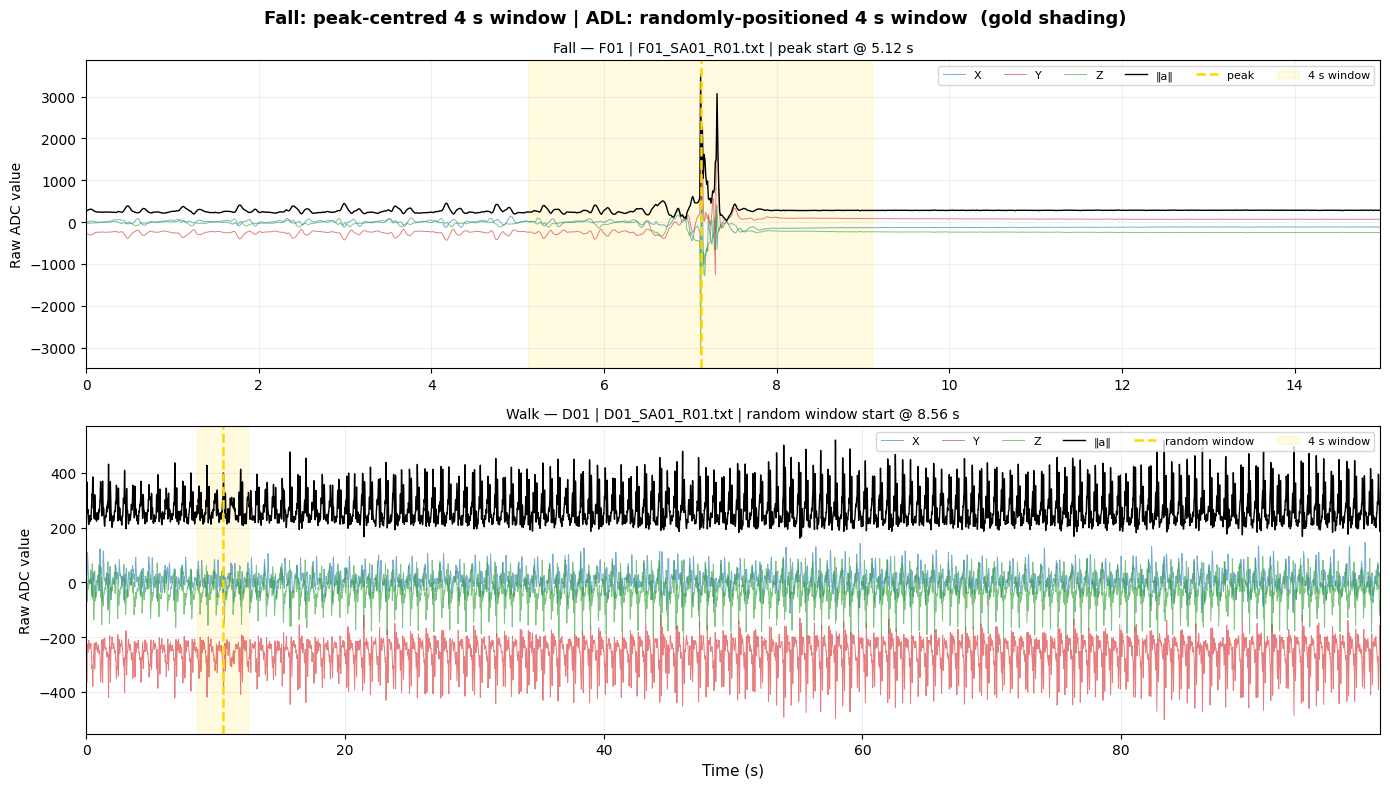

In [5]:
def load_window_for_vis(label_filter, code_filter=None, vis_rng=None):
    for subj in sorted(os.listdir(SISFALL_PATH)):
        subj_path = os.path.join(SISFALL_PATH, subj)
        if not os.path.isdir(subj_path):
            continue
        for fname in sorted(os.listdir(subj_path)):
            if not fname.endswith('.txt'):
                continue
            code = fname.split('_')[0]
            if CODE_TO_LABEL.get(code) != label_filter:
                continue
            if code_filter and code != code_filter:
                continue
            raw = parse_sisfall_txt(os.path.join(subj_path, fname))
            if raw is None or len(raw) < WINDOW * 2:
                continue
            acc_raw = raw[::2][:, 0:3]
            if label_filter == 0:
                _, marker_idx = extract_peak_window(acc_raw, window=WINDOW)
                start_idx = max(0, min(marker_idx - HALF_WINDOW, len(acc_raw) - WINDOW))
                marker_label = 'peak'
            else:
                _, start_idx = extract_random_window(acc_raw, window=WINDOW, rng=vis_rng)
                marker_idx   = start_idx + HALF_WINDOW
                marker_label = 'random window'
            return acc_raw, marker_idx, start_idx, marker_label, fname
    return None, None, None, None, None


vis_rng = np.random.default_rng(RANDOM_SEED)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
AXIS_COLORS = ['#1f77b4', '#d62728', '#2ca02c']

for ax, (lbl, code_f, title_tag) in zip(axes, [
        (0, 'F01', 'Fall \u2014 F01'),
        (2, 'D01', 'Walk \u2014 D01'),
]):
    acc_raw, marker_idx, start_idx, marker_label, fname = load_window_for_vis(lbl, code_f, vis_rng)
    if acc_raw is None:
        ax.set_title(f'{title_tag}: no file found')
        continue
    t   = np.arange(len(acc_raw)) / 100.0
    mag = np.linalg.norm(acc_raw, axis=1)
    for i, (aname, color) in enumerate(zip(['X', 'Y', 'Z'], AXIS_COLORS)):
        ax.plot(t, acc_raw[:, i], color=color, linewidth=0.7, alpha=0.6, label=aname)
    ax.plot(t, mag, color='black', linewidth=1.0, label='\u2016a\u2016')
    ax.axvline(t[marker_idx], color='gold', linewidth=1.8, linestyle='--', label=marker_label)
    ax.axvspan(t[start_idx], t[start_idx + WINDOW - 1], alpha=0.12, color='gold', label='4 s window')
    ax.set_xlim(0, t[-1])
    ax.set_title(f'{title_tag} | {fname} | {marker_label} start @ {t[start_idx]:.2f} s', fontsize=10)
    ax.set_ylabel('Raw ADC value')
    ax.legend(loc='upper right', fontsize=8, ncol=6)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (s)', fontsize=11)
fig.suptitle(
    'Fall: peak-centred 4 s window | ADL: randomly-positioned 4 s window  (gold shading)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 6. Visualise Sample Windows

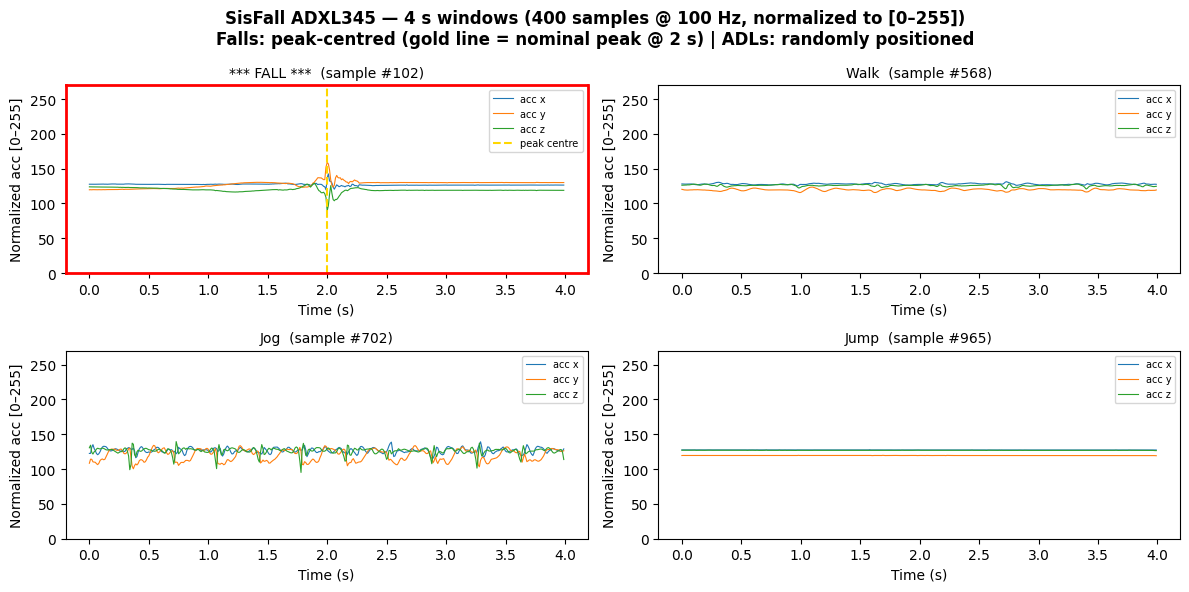

In [6]:
np.random.seed(RANDOM_SEED)
show_labels = [0, 2, 3, 4]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, label in zip(axes.flat, show_labels):
    idxs     = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    acc_data = X_acc[sample_i].reshape(WINDOW, 3)   # (400, 3)
    t        = np.arange(WINDOW) / 100.0              # 0 … 4 s
    for i, (aname, color) in enumerate(zip(['x', 'y', 'z'], colors)):
        ax.plot(t, acc_data[:, i], color=color, linewidth=0.8, label=f'acc {aname}')
    if label == 0:
        ax.axvline(2.0, color='gold', linewidth=1.5, linestyle='--', label='peak centre')
    tag = '*** FALL ***' if label == 0 else CLASS_NAMES[label]
    ax.set_title(f'{tag}  (sample #{sample_i})', fontsize=10)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized acc [0\u2013255]')
    ax.legend(fontsize=7)
    ax.set_ylim(0, 270)
    if label == 0:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

fig.suptitle(
    'SisFall ADXL345 \u2014 4 s windows (400 samples @ 100 Hz, normalized to [0\u2013255])\n'
    'Falls: peak-centred (gold line = nominal peak @ 2 s) | ADLs: randomly positioned',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

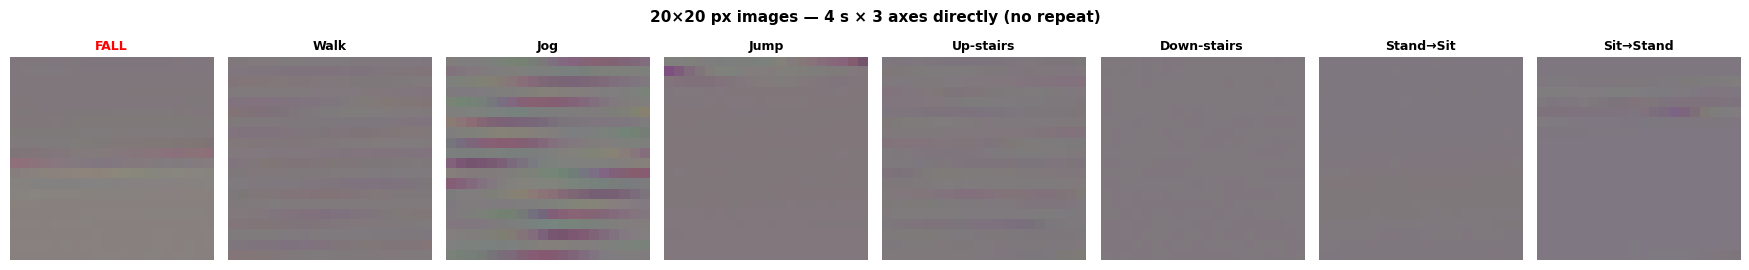

In [7]:
def to_image(acc_flat):
    """Reshape 1200-value vector directly to 20×20×3 image in [0, 1]."""
    return acc_flat.reshape(20, 20, 3) / 255.0


np.random.seed(7)
fig, axes = plt.subplots(1, len(CLASS_LIST), figsize=(2.2 * len(CLASS_LIST), 2.8))
for ax, label in zip(axes, CLASS_LIST):
    idxs     = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    ax.imshow(to_image(X_acc[sample_i]))
    tag = 'FALL' if label == 0 else CLASS_NAMES[label]
    ax.set_title(tag, fontsize=9, color='red' if label == 0 else 'black', fontweight='bold')
    ax.axis('off')

fig.suptitle(
    '20\u00d720 px images \u2014 4 s × 3 axes directly (no repeat)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 7. Equal Per-Class Train / Test Split and Save CSVs

The split is performed independently within each label so every category is balanced in both the training CSV and the test CSV.

In [8]:
split_rng = np.random.default_rng(RANDOM_SEED)

TEST_PER_CLASS  = int(round(TARGET * TEST_SIZE))
TEST_PER_CLASS  = max(1, min(TARGET - 1, TEST_PER_CLASS))
TRAIN_PER_CLASS = TARGET - TEST_PER_CLASS

train_indices = []
test_indices  = []

for lbl in CLASS_LIST:
    idxs = np.where(y == lbl)[0]
    if len(idxs) != TARGET:
        raise ValueError(f'Class {lbl} has {len(idxs)} samples; expected TARGET={TARGET}')
    idxs = split_rng.permutation(idxs)
    test_indices.extend(idxs[:TEST_PER_CLASS])
    train_indices.extend(idxs[TEST_PER_CLASS:TEST_PER_CLASS + TRAIN_PER_CLASS])

idx_train = split_rng.permutation(np.array(train_indices, dtype=int))
idx_test  = split_rng.permutation(np.array(test_indices, dtype=int))

X_acc_train, X_acc_test = X_acc[idx_train], X_acc[idx_test]
y_train,     y_test     = y[idx_train],     y[idx_test]

print(f'Train: {len(X_acc_train)} samples | Test: {len(X_acc_test)} samples')
print(f'Per class: train={TRAIN_PER_CLASS}, test={TEST_PER_CLASS}')
print()
print(f'{"Class":>12s}  {"Train":>7}  {"Test":>6}')
print('-' * 32)
for lbl in CLASS_LIST:
    print(f'{CLASS_NAMES[lbl]:>12s}  {(y_train == lbl).sum():>7}  {(y_test == lbl).sum():>6}')

Train: 1904 samples | Test: 480 samples
Per class: train=238, test=60

       Class    Train    Test
--------------------------------
        Fall      238      60
        Walk      238      60
         Jog      238      60
        Jump      238      60
   Up-stairs      238      60
 Down-stairs      238      60
   Stand→Sit      238      60
   Sit→Stand      238      60


In [9]:
col_names = ['label'] + [str(i + 1) for i in range(WINDOW * 3)]

train_df = pd.DataFrame(np.column_stack([y_train.astype(float), X_acc_train]), columns=col_names)
train_df['label'] = y_train
train_df.to_csv(TRAIN_CSV, index=False)

test_df = pd.DataFrame(np.column_stack([y_test.astype(float), X_acc_test]), columns=col_names)
test_df['label'] = y_test
test_df.to_csv(TEST_CSV, index=False)

print(f'Saved  {TRAIN_CSV}  ({len(train_df)} rows, {WINDOW * 3} values each)')
print(f'Saved  {TEST_CSV}   ({len(test_df)} rows, {WINDOW * 3} values each)')

Saved  data/sisfall_peak4s_random_balanced_train.csv  (1904 rows, 1200 values each)
Saved  data/sisfall_peak4s_random_balanced_test.csv   (480 rows, 1200 values each)


## 8. Build Model Inputs

No repeat needed — the 4 s window already produces 400 × 3 = **1200 values** per sample, matching the CNN's expected input shape exactly.

In [10]:
def to_onehot(labels_arr, class_list):
    y_oh = np.zeros((len(labels_arr), len(class_list)), dtype=np.float32)
    for i, lbl in enumerate(labels_arr):
        y_oh[i, class_list.index(lbl)] = 1.0
    return y_oh


X_model_train = X_acc_train.astype(np.float32)   # (N_train, 1200)
X_model_test  = X_acc_test.astype(np.float32)    # (N_test,  1200)
y_train_oh    = to_onehot(y_train, CLASS_LIST)
y_test_oh     = to_onehot(y_test,  CLASS_LIST)

print(f'Train input: {X_model_train.shape}  |  Test input: {X_model_test.shape}')
print(f'Value range: [{X_model_train.min():.1f}, {X_model_train.max():.1f}]')

Train input: (1904, 1200)  |  Test input: (480, 1200)
Value range: [0.0, 254.8]


## 9. Build TF Graph and Train

In [11]:
TRAIN_STEPS   = 5000
BATCH_SIZE    = 50
LEARNING_RATE = 0.001

tf.reset_default_graph()

x_ph = tf.placeholder(tf.float32, [None, 1200], name='input')
y_ph = tf.placeholder(tf.float32, [None, CLASS_NUM], name='labels')

logits, keep_prob_ph = cnn_module.fall_net(x_ph)

loss_op    = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(labels=y_ph, logits=logits))
train_op   = tf.train.AdamOptimizer(LEARNING_RATE).minimize(loss_op)
correct_op = tf.equal(tf.argmax(logits, 1), tf.argmax(y_ph, 1))
acc_op     = tf.reduce_mean(tf.cast(correct_op, tf.float32))
probs_op   = tf.nn.softmax(logits)

saver = tf.train.Saver()
sess  = tf.Session()
sess.run(tf.global_variables_initializer())

print(f'Graph built. Training on {len(X_model_train)} samples for {TRAIN_STEPS} steps...')

Graph built. Training on 1904 samples for 5000 steps...


E0000 00:00:1776884192.869891   75593 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1776884192.877427   75593 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


In [12]:
n_train = len(X_model_train)
perm    = np.random.permutation(n_train)
ptr     = 0

log_steps, log_loss, log_acc = [], [], []

for step in range(1, TRAIN_STEPS + 1):
    if ptr + BATCH_SIZE > n_train:
        perm = np.random.permutation(n_train)
        ptr  = 0
    batch_idx = perm[ptr:ptr + BATCH_SIZE]
    ptr += BATCH_SIZE

    _, loss_val = sess.run([train_op, loss_op],
                           feed_dict={x_ph: X_model_train[batch_idx],
                                      y_ph: y_train_oh[batch_idx],
                                      keep_prob_ph: 0.5})
    if step % 500 == 0:
        acc_val = acc_op.eval(session=sess,
                              feed_dict={x_ph: X_model_train[batch_idx],
                                         y_ph: y_train_oh[batch_idx],
                                         keep_prob_ph: 1.0})
        log_steps.append(step)
        log_loss.append(loss_val)
        log_acc.append(acc_val)
        print(f'Step {step:5d}  |  loss = {loss_val:.4f}  |  batch acc = {acc_val:.4f}')

save_path = saver.save(sess, MODEL_SAVE_PATH)
print(f'\nModel saved to {save_path}')

Step   500  |  loss = 0.4813  |  batch acc = 0.8600
Step  1000  |  loss = 0.5700  |  batch acc = 0.7800
Step  1500  |  loss = 0.1459  |  batch acc = 0.9800
Step  2000  |  loss = 0.2521  |  batch acc = 0.9400
Step  2500  |  loss = 0.1025  |  batch acc = 1.0000
Step  3000  |  loss = 0.0851  |  batch acc = 0.9400
Step  3500  |  loss = 0.0445  |  batch acc = 1.0000
Step  4000  |  loss = 0.2859  |  batch acc = 0.9800
Step  4500  |  loss = 0.0295  |  batch acc = 1.0000
Step  5000  |  loss = 0.1196  |  batch acc = 0.9600

Model saved to model/sisfall_peak4s_random_balanced_model.ckpt


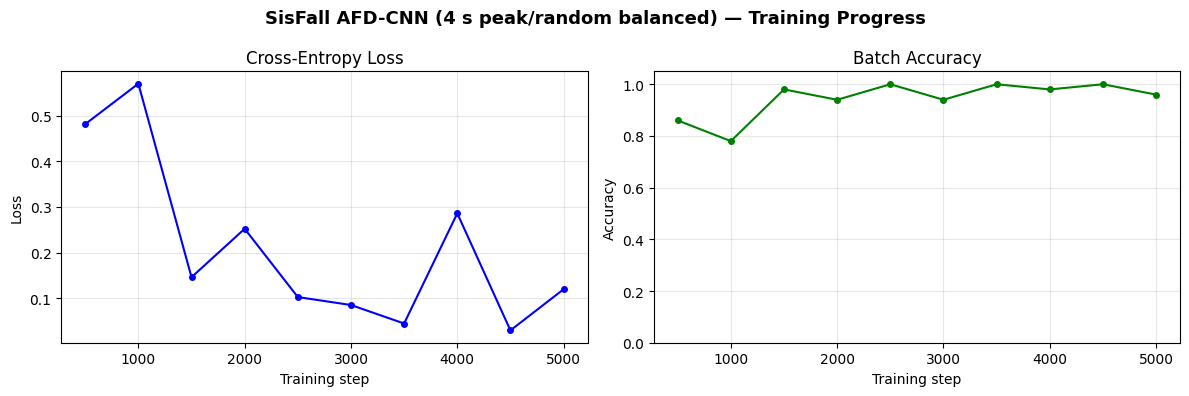

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(log_steps, log_loss, 'b-o', markersize=4)
ax1.set_title('Cross-Entropy Loss')
ax1.set_xlabel('Training step')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(log_steps, log_acc, 'g-o', markersize=4)
ax2.set_title('Batch Accuracy')
ax2.set_xlabel('Training step')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

fig.suptitle('SisFall AFD-CNN (4 s peak/random balanced) \u2014 Training Progress',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Evaluate on Train and Test Sets

In [14]:
def run_inference(X):
    EVAL_BATCH = 256
    all_logits = []
    all_probs  = []
    for start in range(0, len(X), EVAL_BATCH):
        l, p = sess.run([logits, probs_op],
                        feed_dict={x_ph: X[start:start + EVAL_BATCH], keep_prob_ph: 1.0})
        all_logits.append(l)
        all_probs.append(p)
    all_logits  = np.vstack(all_logits)
    all_probs   = np.vstack(all_probs)
    pred_idx    = np.argmax(all_probs, axis=1)
    pred_labels = np.array([CLASS_LIST[i] for i in pred_idx])
    return pred_labels, all_probs, all_logits


for split_name, X_split, y_split in [
        ('Train', X_model_train, y_train),
        ('Test',  X_model_test,  y_test)]:

    pred_labels, _, _ = run_inference(X_split)
    overall = np.mean(pred_labels == y_split)

    print(f'=== {split_name} set ({len(y_split)} samples) ===')
    print(f'Overall accuracy: {overall:.4f}  ({overall:.2%})')
    print(f'{"Class":>12s}  {"N":>5}  {"Sensitivity":>12}  {"Specificity":>12}')
    print('-' * 48)
    for lbl in CLASS_LIST:
        acc, sens, spec = cnn_module.evaluate(pred_labels, y_split, lbl)
        n_cls = int((y_split == lbl).sum())
        print(f'{CLASS_NAMES[lbl]:>12s}  {n_cls:>5}  {sens:>12.4f}  {spec:>12.4f}')
    print()

=== Train set (1904 samples) ===
Overall accuracy: 0.9816  (98.16%)
       Class      N   Sensitivity   Specificity
------------------------------------------------
        Fall    238        1.0000        1.0000
        Walk    238        1.0000        1.0000
         Jog    238        1.0000        1.0000
        Jump    238        0.9706        0.9994
   Up-stairs    238        0.9790        1.0000
 Down-stairs    238        0.9664        0.9928
   Stand→Sit    238        0.9832        0.9892
   Sit→Stand    238        0.9538        0.9976

=== Test set (480 samples) ===
Overall accuracy: 0.8729  (87.29%)
       Class      N   Sensitivity   Specificity
------------------------------------------------
        Fall     60        1.0000        0.9952
        Walk     60        1.0000        0.9976
         Jog     60        1.0000        1.0000
        Jump     60        0.9167        0.9976
   Up-stairs     60        0.9500        0.9976
 Down-stairs     60        0.8667        0.9905

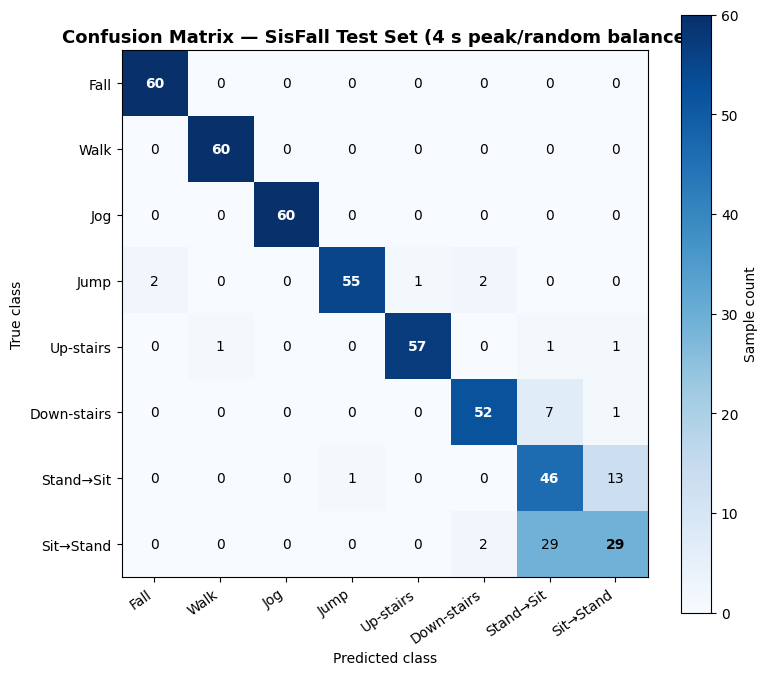

In [15]:
pred_test, _, _ = run_inference(X_model_test)
label_names     = [CLASS_NAMES[l] for l in CLASS_LIST]
cm = confusion_matrix(y_test, pred_test, labels=CLASS_LIST)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, label='Sample count')
ax.set_xticks(range(len(CLASS_LIST)))
ax.set_yticks(range(len(CLASS_LIST)))
ax.set_xticklabels(label_names, rotation=35, ha='right')
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title(
    'Confusion Matrix \u2014 SisFall Test Set (4 s peak/random balanced)',
    fontsize=13, fontweight='bold'
)
for i in range(len(CLASS_LIST)):
    for j in range(len(CLASS_LIST)):
        val    = cm[i, j]
        color  = 'white' if val > cm.max() / 2 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=10, color=color, fontweight=weight)

plt.tight_layout()
plt.show()

## 11. Fall Logit and P(Fall) Distributions by True Label

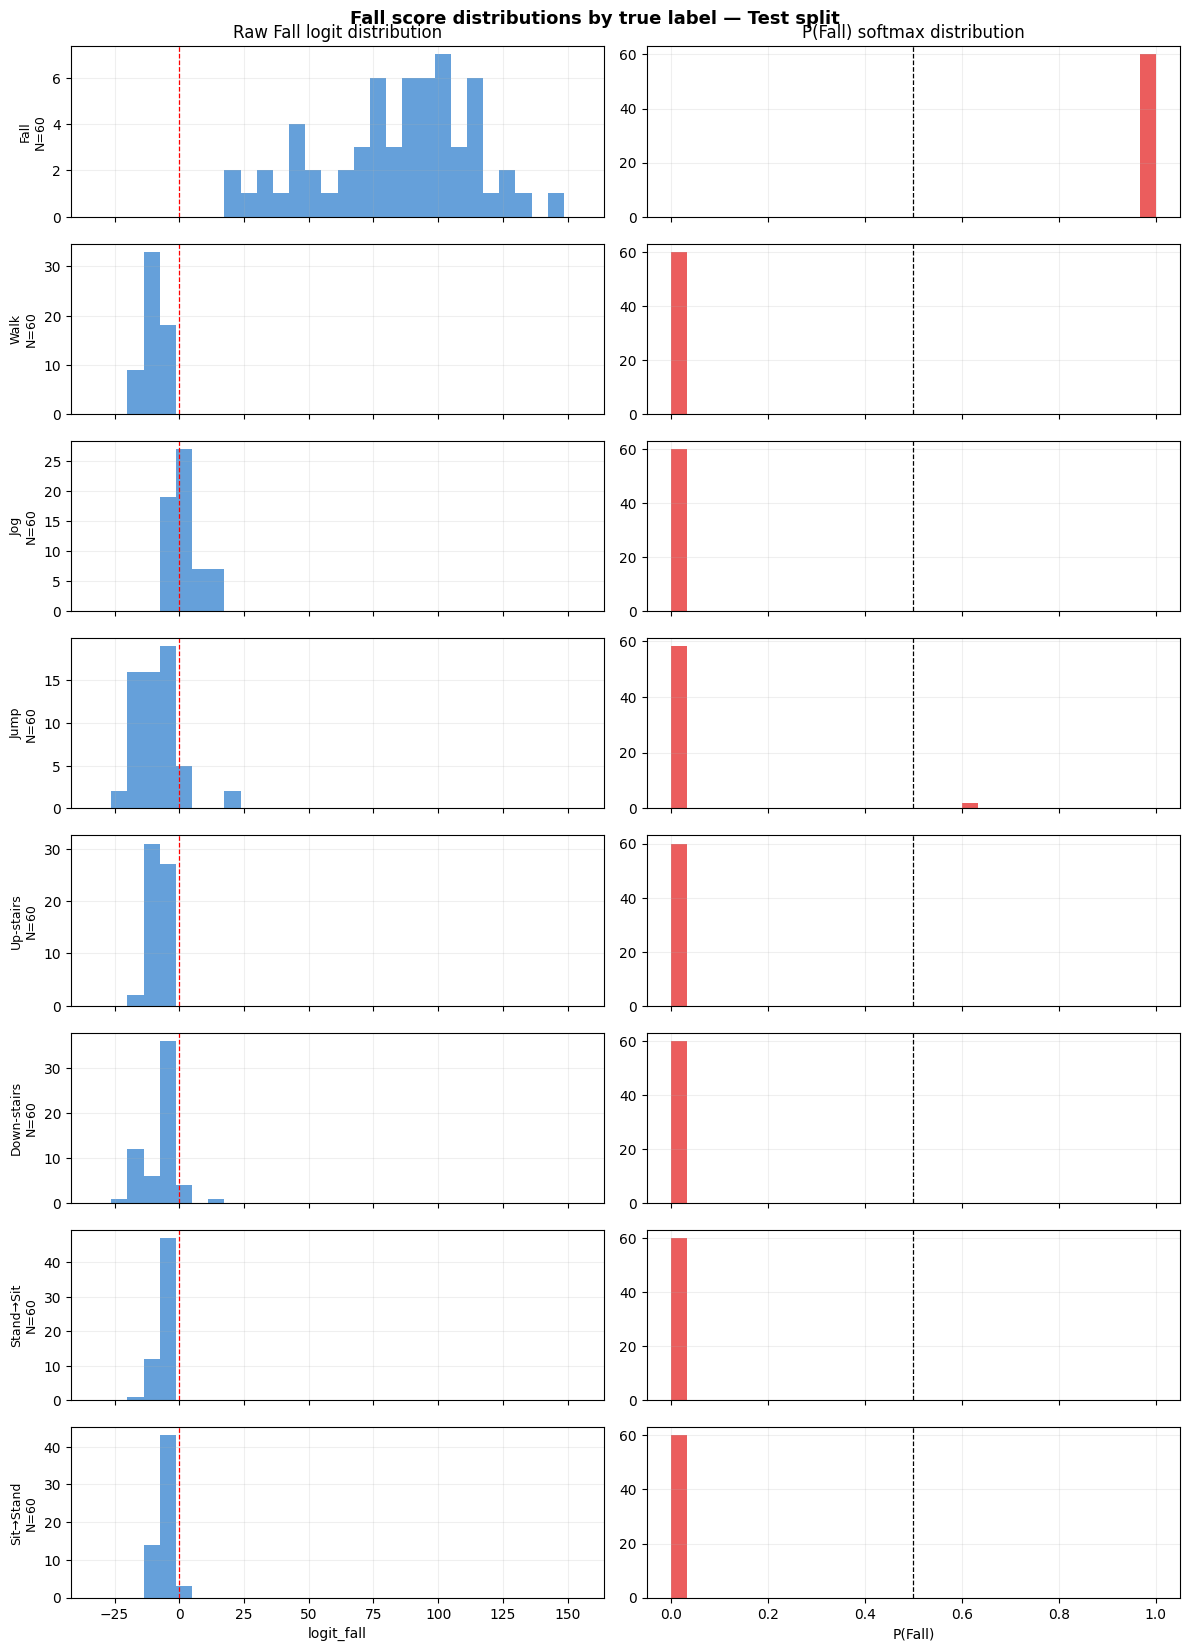

=== Fall score distribution summary ===
 label  class_name  n  mean_logit_fall  median_logit_fall  mean_prob_fall  median_prob_fall  max_prob_fall
     0        Fall 60        83.893082          89.221741    9.999998e-01      9.999999e-01       1.000000
     2        Walk 60       -10.030137          -9.857116    7.342053e-07      6.034821e-15       0.000044
     3         Jog 60         1.646636           0.122105    8.287777e-08      6.723402e-14       0.000005
     4        Jump 60        -8.669483          -9.015968    2.037297e-02      5.243898e-14       0.609821
     5   Up-stairs 60        -8.103464          -7.653744    2.042379e-05      1.316931e-08       0.000727
     6 Down-stairs 60        -7.405507          -5.440136    1.847809e-04      1.542621e-05       0.001541
     7   Stand→Sit 60        -6.026228          -5.757863    4.304217e-05      4.297407e-08       0.001043
     9   Sit→Stand 60        -5.827362          -5.876487    9.139399e-05      5.400354e-09       0.0018

In [16]:
DIST_SPLIT = 'Test'
X_dist = X_model_test if DIST_SPLIT == 'Test' else X_model_train
y_dist = y_test        if DIST_SPLIT == 'Test' else y_train

_, dist_probs, dist_logits = run_inference(X_dist)
fall_idx = CLASS_LIST.index(0)

dist_df = pd.DataFrame({
    'label':      y_dist,
    'class_name': [CLASS_NAMES[int(lbl)] for lbl in y_dist],
    'logit_fall': dist_logits[:, fall_idx],
    'prob_fall':  dist_probs[:, fall_idx],
})

logit_min, logit_max = dist_df['logit_fall'].min(), dist_df['logit_fall'].max()
if np.isclose(logit_min, logit_max):
    logit_min -= 1.0; logit_max += 1.0
logit_pad  = 0.05 * (logit_max - logit_min)
logit_bins = np.linspace(logit_min - logit_pad, logit_max + logit_pad, 31)
prob_bins  = np.linspace(0.0, 1.0, 31)

fig, axes = plt.subplots(len(CLASS_LIST), 2, figsize=(12, 2.1 * len(CLASS_LIST)), sharex='col')

for row_idx, lbl in enumerate(CLASS_LIST):
    cls = dist_df[dist_df['label'] == lbl]
    ax_logit, ax_prob = axes[row_idx]
    ax_logit.hist(cls['logit_fall'], bins=logit_bins, color='#4a8fd4', alpha=0.85)
    ax_logit.axvline(0, color='red', ls='--', lw=0.9)
    ax_logit.set_ylabel(f'{CLASS_NAMES[lbl]}\nN={len(cls)}', fontsize=9)
    ax_logit.grid(True, alpha=0.2)
    ax_prob.hist(cls['prob_fall'], bins=prob_bins, color='#e84040', alpha=0.85)
    ax_prob.axvline(0.5, color='black', ls='--', lw=0.9)
    ax_prob.grid(True, alpha=0.2)

axes[0, 0].set_title('Raw Fall logit distribution')
axes[0, 1].set_title('P(Fall) softmax distribution')
axes[-1, 0].set_xlabel('logit_fall')
axes[-1, 1].set_xlabel('P(Fall)')
fig.suptitle(f'Fall score distributions by true label \u2014 {DIST_SPLIT} split',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

summary = (
    dist_df
    .groupby(['label', 'class_name'])
    .agg(n=('prob_fall', 'size'),
         mean_logit_fall=('logit_fall', 'mean'),
         median_logit_fall=('logit_fall', 'median'),
         mean_prob_fall=('prob_fall', 'mean'),
         median_prob_fall=('prob_fall', 'median'),
         max_prob_fall=('prob_fall', 'max'))
    .reset_index()
)

print('=== Fall score distribution summary ===')
print(summary.to_string(index=False))

sess.close()
print('Training complete. Session closed.')
print(f'Checkpoint: {MODEL_SAVE_PATH}')
print(f'Test CSV:   {TEST_CSV}')